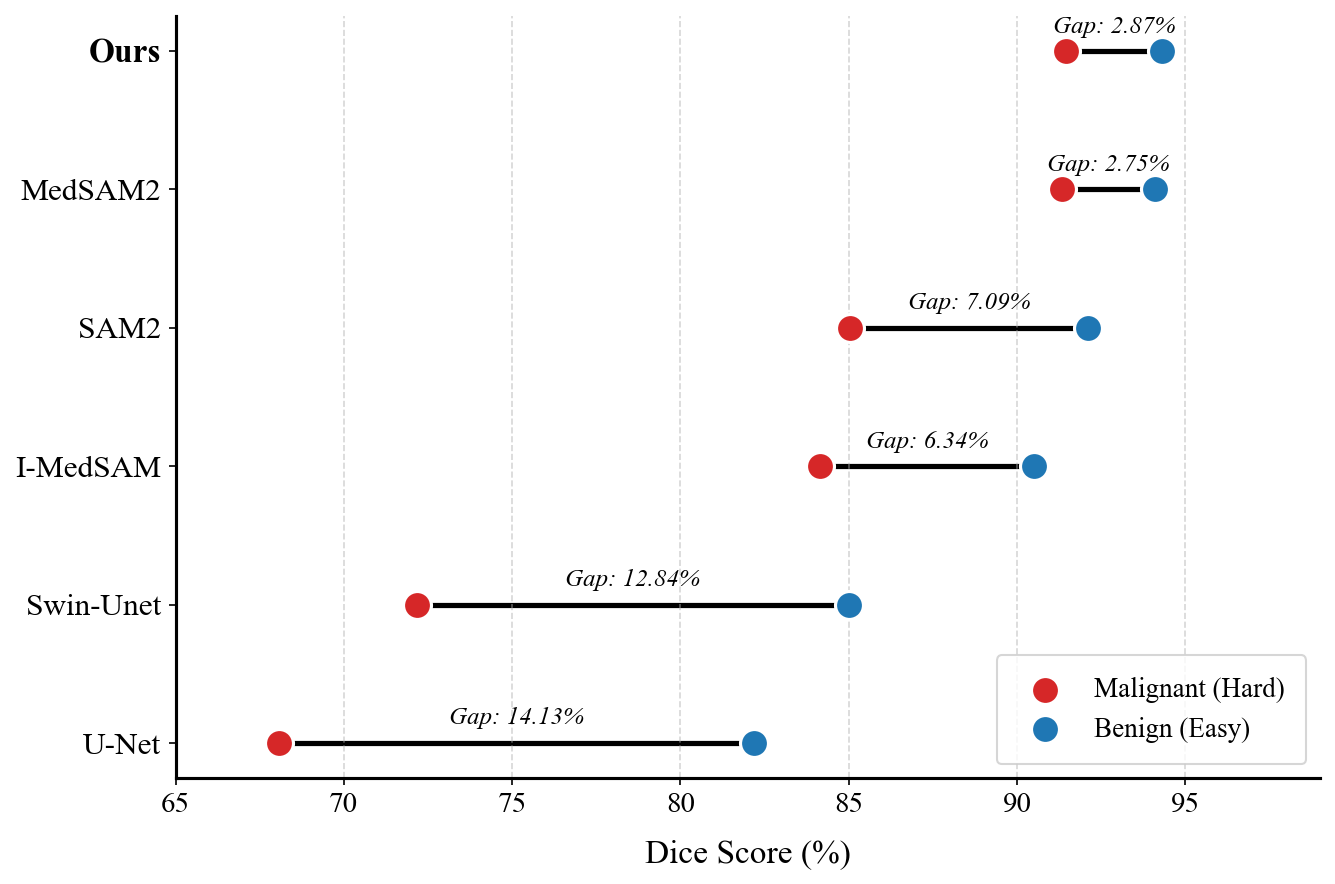

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据 (根据您表格中的最新数据)
methods = ["U-Net", "Swin-Unet", "I-MedSAM", "SAM2", "MedSAM2", "Ours"]
# 注意：Matplotlib 是从下往上画的，所以Ours在列表最后，画出来会在最上面

benign_scores = [82.19, 85.00, 90.50, 92.12, 94.09, 94.32]
malignant_scores = [68.06, 72.16, 84.16, 85.03, 91.34, 91.45]

# 自动计算差距 (保证绘图几何准确)
gaps = [b - m for b, m in zip(benign_scores, malignant_scores)]

# 2. 设置绘图风格
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.linewidth'] = 1.5 # 坐标轴线变粗

# 增加画布高度，给大字体留空间
fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

# Y轴位置
y_pos = np.arange(len(methods))

# 3. 绘制哑铃图
for i in range(len(methods)):
    # 绘制连接线 (Gap)
    if methods[i] == " ":
        line_color = 'black'
        line_width = 2.5 # 线加粗
        alpha = 1.0
        gap_fontsize = 13 # Ours的标注字体更大
        gap_weight = 'bold'
    else:
        line_color = 'black'
        line_width = 2.5
        alpha = 1.0
        gap_fontsize = 12 # 普通标注字体
        gap_weight = 'normal'
        
    ax.plot([malignant_scores[i], benign_scores[i]], [i, i], 
            color=line_color, linewidth=line_width, zorder=1, alpha=alpha)
    
    # 在线中间标注 Gap 数值 (字体放大)
    mid_point = (benign_scores[i] + malignant_scores[i]) / 2
    # 文字位置微调，y轴偏移量加大以防压线
    ax.text(mid_point, i + 0.18, f"Gap: {gaps[i]:.2f}%", 
            ha='center', va='center', fontsize=gap_fontsize, 
            color=line_color, fontweight=gap_weight, style='italic')

# 4. 绘制点 (点也放大)
dot_size = 180 # 点的大小从100增加到180

# Malignant (难样本)
ax.scatter(malignant_scores, y_pos, color='#D62728', label='Malignant (Hard)', 
           s=dot_size, zorder=2, marker='o', edgecolors='white', linewidth=1.5)

# Benign (易样本)
ax.scatter(benign_scores, y_pos, color='#1F77B4', label='Benign (Easy)', 
           s=dot_size, zorder=2, marker='o', edgecolors='white', linewidth=1.5)

# 5. 美化图表 (关键：字体全部放大)

# Y轴标签 (方法名)
ax.set_yticks(y_pos)
ax.set_yticklabels(methods, fontsize=15) # 放大到15

# 给 Ours 加粗
yticklabels = ax.get_yticklabels()
yticklabels[-1].set_fontweight('bold') 
yticklabels[-1].set_fontsize(16) # Ours 再大一点

# X轴标签
ax.set_xlabel('Dice Score (%)', fontsize=16, labelpad=10) # 放大到16
ax.set_xlim(65, 99) 
ax.tick_params(axis='x', labelsize=14) # X轴刻度放大到14

# 网格线
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

# 移除边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 图例 (放大)
ax.legend(loc='lower right', fontsize=13, frameon=True, borderpad=0.8)

plt.tight_layout()

# 保存
plt.savefig('gap_analysis_large_font.pdf', format='pdf', bbox_inches='tight')
plt.savefig('gap_analysis_large_font.png', format='png', dpi=300, bbox_inches='tight')

plt.show()